In [1]:
# Import required packages
import anndict as adt
import scanpy as sc
adt.configure_llm_backend('openai',
    'gpt-4o',
    api_key='Your API key'
)
adata = sc.read_h5ad('/maiziezhou_lab2/yuling/datasets/HumanLymph/spatial_data.h5ad')
adata.obs['tissue'] = 'human metastatic lymph node'
sc.pp.normalize_total(adata) # Normalize
sc.pp.log1p(adata) # Log
sc.pp.highly_variable_genes(adata, n_top_genes= 2000, subset=False) # Set highly variable genes
sc.pp.scale(adata) # Scale
sc.tl.pca(adata, n_comps=50) # PCA
sc.pp.neighbors(adata) # Neighborhood graph
sc.tl.umap(adata) # UMAP
adata_dict = adt.build_adata_dict(adata, ['tissue'])
#appropriate_resolution_dict = adt.wrappers.ai_determine_leiden_resolution_adata_dict(adata_dict, initial_resolution=0.5)
sc.tl.leiden(adata, resolution = 0.4) # Cluster
sc.tl.rank_genes_groups(adata, groupby='leiden', use_raw=False)
# Get the model name directly from the LLM config (just for naming the column in .obs)
model = adt.get_llm_config()['model']
# Use an LLM to annotate celltypes based on the 'leiden' column, pass tissue information from 'tissue' column.
# The column containing the new labels will be in adata.obs[label_column]
new_label_column = f'{model}_ai_cell_type'
label_results = adt.ai_annotate_cell_type(adata, groupby='leiden', n_top_genes=10, new_label_column=new_label_column, tissue_of_origin_col='tissue')
# These labels may have some redundancy, so merge them with the LLM
ai_label_column = f'{model}_simplified_ai_cell_type'
simplified_mappings = adt.simplify_obs_column(adata, new_label_column, ai_label_column, simplification_level='redundancy-removed')

/home/zhuy45/miniconda3/envs/adt/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/home/zhuy45/miniconda3/envs/adt/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_107001/4158252539.py:21: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution = 0.4) # Cluster
/home/zhuy45/miniconda3/envs/adt/lib/python3.12/site-packages/scanpy/tools/_rank_ge

In [3]:
import pandas as pd 
pd.DataFrame(adata.obs['gpt-4o_ai_cell_type'].unique()).to_csv('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/AnnDictionary/GPT_Human.csv')

In [6]:
import pandas as pd

# ====== config ======
col = "gpt-4o_ai_cell_type"
new_col = f"{col}_renamed"

# unique labels in appearance order
u = pd.Series(adata.obs[col].astype(str).unique()).reset_index(drop=True)

print(f"Total unique = {len(u)}")
print("Index -> original label:")
for i, txt in enumerate(u):
    print(f"[{i}] {txt[:120]}{'...' if len(txt) > 120 else ''}")

# ====== fill this mapping (0-9) ======
idx_to_name = {
    0: "Fibroblasts",
    1: "B cells",
    2: "Ribosomal protein-expressing cells",
    3: "Keratinocyte",
    4: "Immune cells",
    5: "Metastatic cancer cells",
    6: "Plasma cells",
    7: "Cancer-associated fibroblasts",
    8: "Neutrophils",
    9: "Metastatic squamous carcinoma cells",
    10: "Lymphocytes",
    11: "Follicular helper T cells",
    12: "Cancer cells",
    13: "Mast cells",
    14: "Macrophage",
    15: "Neuronal-like cells",
    16: "Ribosomal protein-expressing cells",
    17: "Ribosomal protein-expressing cells",
    18: "Ribosomal protein-expressing cells"
}

# ====== apply ======
# convert index mapping -> text mapping
text_map = {u.iloc[i]: v for i, v in idx_to_name.items() if i < len(u)}

# replace; labels not in idx_to_name stay original
s = adata.obs[col].astype(str)
adata.obs[new_col] = s.replace(text_map)

# optional: if you want ONLY your new names, mark others as "Unknown"
# adata.obs[new_col] = adata.obs[new_col].where(adata.obs[new_col].isin(idx_to_name.values()), "Unknown")

# categorical
adata.obs[new_col] = adata.obs[new_col].astype("category")

print("\nNew value counts:")
print(adata.obs[new_col].value_counts(dropna=False))
print("\nNew categories:")
print(list(adata.obs[new_col].cat.categories))

Total unique = 19
Index -> original label:
[0] Fibroblasts
[1] B cells
[2] Ribosomal protein-expressing cells, likely cancer cells
[3] Keratinocyte
[4] Immune cells
[5] Metastatic cancer cells
[6] Plasma cells
[7] Cancer-associated fibroblasts
[8] Neutrophils
[9] Metastatic squamous carcinoma cells
[10] Lymphocytes
[11] Follicular helper T cells
[12] Cancer cells
[13] Mast cells
[14] Macrophage
[15] Neuronal-like cells
[16] Ribosomal protein-rich, likely cancer cells
[17] Ribosomal protein-rich, likely lymphocytes
[18] Ribosomal protein-rich, likely B cells

New value counts:
gpt-4o_ai_cell_type_renamed
Ribosomal protein-expressing cells     15586
Metastatic squamous carcinoma cells     8319
Fibroblasts                             4752
Plasma cells                            4733
B cells                                 1865
Keratinocyte                             668
Neuronal-like cells                      610
Mast cells                               490
Neutrophils                  

Plotting UMAP for key: human metastatic lymph node


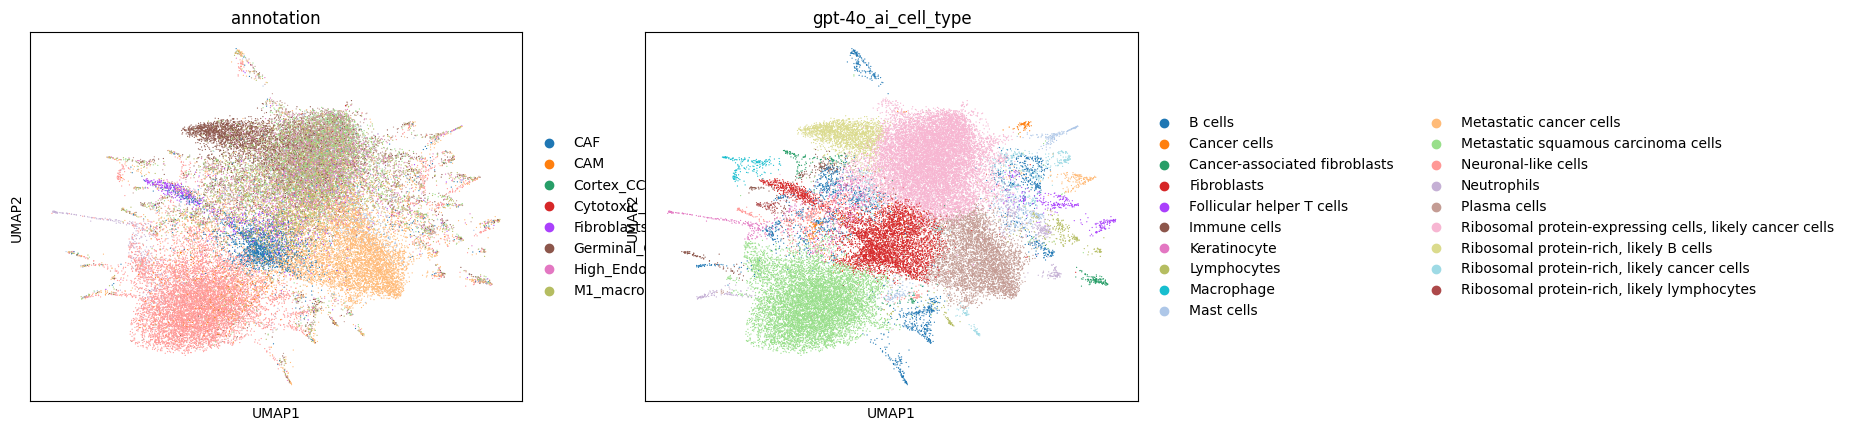

In [7]:
adata_1_dict = {'human metastatic lymph node': adata}
adt.wrappers.plot_umap_adata_dict(adata_1_dict, color=['annotation', 'gpt-4o_ai_cell_type'])

In [8]:

rows = [
    "Tumor",
    "Plasma_IgG",
    "unknown",
    "Germinal_Center_Plasma_IgM_B_cell",
    "CAF",
    "Fibroblasts",
    "Plasma_IgA",
    "Cortex_CCL21",
    "Cytotoxic_IFN_signaling",
    "Macrophages",
    "CAM",
    "Tumor_Keratin_Pearl",
    "M1_macrophages",
    "High_Endothelial_Venules",
    "T_cell"
]

annot_to_cluster = [
    "Cancer cells",
    "Metastatic cancer cells",
    "Metastatic squamous carcinoma cells",
    "Keratinocyte",

    "Cancer-associated fibroblasts",
    "Fibroblasts",

    "Plasma cells",
    "B cells",
    "Ribosomal protein-expressing cells",

    "Follicular helper T cells",
    "Lymphocytes",
    "Immune cells",

    "Macrophage",
    "Neutrophils",
    "Mast cells",

    "Neuronal-like cells"
]
pred_order_by_rows_unique = list(dict.fromkeys(annot_to_cluster))
print(pred_order_by_rows_unique)
adata.obs["annotation"] = pd.Categorical(
    adata.obs["annotation"],
    categories= rows,
    ordered=True
)

adata.obs["gpt-4o_ai_cell_type_renamed"] = pd.Categorical(
    adata.obs["gpt-4o_ai_cell_type_renamed"],
    categories= pred_order_by_rows_unique,
    ordered=True
)

['Cancer cells', 'Metastatic cancer cells', 'Metastatic squamous carcinoma cells', 'Keratinocyte', 'Cancer-associated fibroblasts', 'Fibroblasts', 'Plasma cells', 'B cells', 'Ribosomal protein-expressing cells', 'Follicular helper T cells', 'Lymphocytes', 'Immune cells', 'Macrophage', 'Neutrophils', 'Mast cells', 'Neuronal-like cells']


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) Confusion matrix (raw counts)
# =========================
conf_mat = pd.crosstab(
    adata.obs["annotation"],
    adata.obs["gpt-4o_ai_cell_type_renamed"],
    dropna=False
)

conf_mat = conf_mat.reindex(
    index= rows,
    columns= pred_order_by_rows_unique
)

# =========================
# 2) Row-wise normalization
#    (each row sums to 1)
# =========================
conf_mat_row_norm = conf_mat.div(
    conf_mat.sum(axis=1).replace(0, np.nan),
    axis=0
)
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["font.family"] = "Arial" 
# =========================
# 3) Plot heatmap
# =========================
plt.figure(figsize=(12, 8))

sns.heatmap(
    conf_mat_row_norm,
    cmap="RdYlBu_r",
    annot=True,
    fmt=".2f",                 # proportions
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "Proportion"}
)

plt.xlabel("Predicted cell type", size= 16)
plt.ylabel("Ground truth cell type", size= 16)
plt.title("Row-normalized confusion matrix (Open-ST Human metastatic lymph node)", size=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(
    "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/AnnDictionary/confusion_GPTHuman0316.pdf",
    format="pdf",
    bbox_inches="tight",
)
plt.close()


In [10]:
manual_cell_type_col = 'annotation'
label_map_with_manual = adt.ensure_label_consistency_adata(adata, ["gpt-4o_ai_cell_type_renamed", manual_cell_type_col], simplification_level='unified', new_col_prefix='unified')

In [11]:
unified_cell_types = adt.get_adata_columns(adata, contains=['unified'])
unified_cell_types

['unified_annotation', 'unified_gpt-4o_ai_cell_type_renamed']

In [12]:
label_agreement_binary = adt.ai_compare_cell_type_labels_pairwise(adata, [unified_cell_types[0]], [unified_cell_types[1]], new_col_prefix='binary_agreement', comparison_level='binary')
label_agreement_categorical = adt.ai_compare_cell_type_labels_pairwise(adata, [unified_cell_types[0]], [unified_cell_types[1]], new_col_prefix='categorical_agreement', comparison_level='categorical')

In [13]:
binary_agreement_cols = adt.get_adata_columns(adata, contains = ['binary_agreement'])
categorical_agreement_cols = adt.get_adata_columns(adata, contains = ['categorical_agreement'])

In [14]:
adata.obs[categorical_agreement_cols] = adata.obs[categorical_agreement_cols]/2

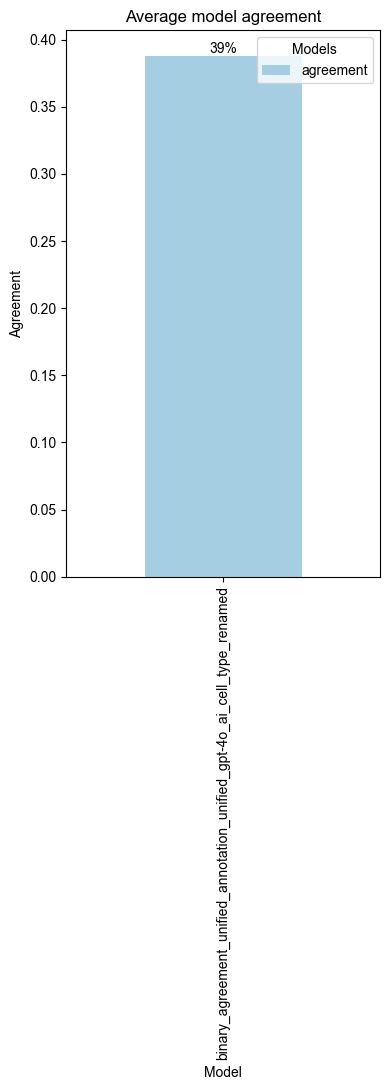

In [15]:
#plot the agreement at the binary level
agreement_plot_overall_binary = adt.plot_model_agreement(adata, group_by=manual_cell_type_col, sub_group_by='tissue', agreement_cols=binary_agreement_cols, granularity=0)

#clean plot up for display
import matplotlib.pyplot as plt
def set_xticks_rotation_and_resize(fig_ax_tuple):
    fig, ax = fig_ax_tuple
    fig.set_size_inches((4, 11))
    fig.tight_layout()  # Adjust layout to fit the new size
    
    # Rotate x-axis tick labels
    for label in ax.get_xticklabels():
        label.set_rotation(90)
    # Check if legend exists and update labels if necessary
    legend = ax.get_legend()
    if legend:
        # Define label mapping
        label_mapping = {'0.0': 'No', '0.5': 'Partial', '1.0': 'Perfect'}
        
        # Iterate over legend texts and update if in mapping
        for text in legend.get_texts():
            original_label = text.get_text()
            new_label = label_mapping.get(original_label, original_label)
            text.set_text(new_label)
set_xticks_rotation_and_resize(agreement_plot_overall_binary)